In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
cluster_data = pd.read_csv('../results/autoencoder/csv/cluster_stats_left.csv')
cluster_pain_data = pd.read_csv('../results/autoencoder_pain/csv/cluster_stats_left.csv')
tabular_input_data_test= pd.read_csv('../results/tabular_input_ae/test/csv/cluster_stats_left.csv')
tabular_input_data_non_test= pd.read_csv('../results/tabular_input_ae/non_test/csv/cluster_stats_left.csv')
kl_data = pd.read_csv('../csv/kl_clusters_left.csv')

/Users/filippofocaccia/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
plt.rcdefaults()

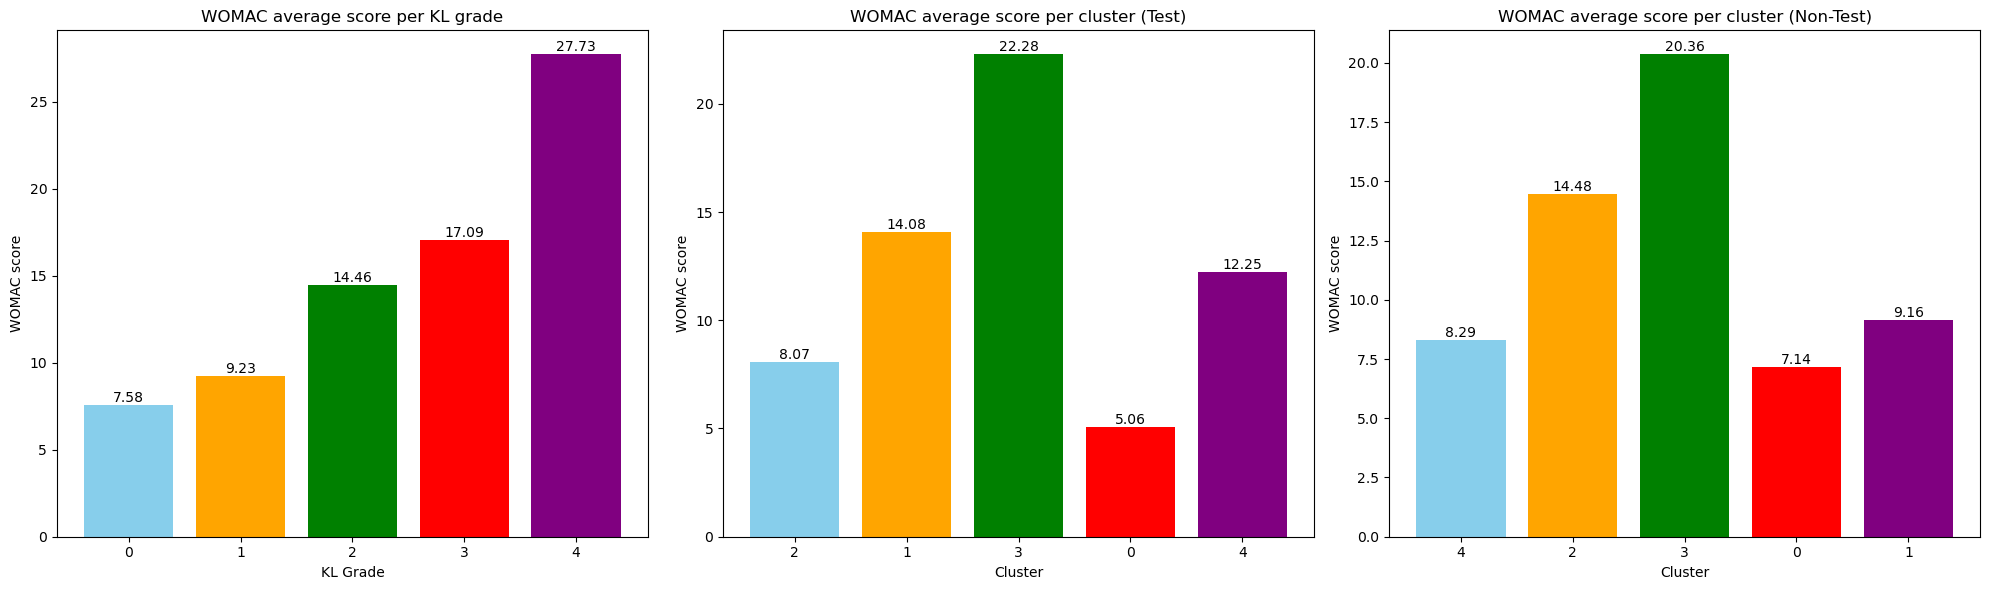

In [2]:
# cluster_data.columns = cluster_data.columns.str.strip()
# cluster_pain_data.columns = cluster_pain_data.columns.str.strip()
kl_data.columns = kl_data.columns.str.strip()
tabular_input_data_test.columns = tabular_input_data_test.columns.str.strip()
tabular_input_data_non_test.columns = tabular_input_data_non_test.columns.str.strip()

#  DEFINE FORCED CLUSTER ORDER
# cluster_order = [4, 1, 2, 0, 3]  # keep same order as earlier
cluster_order = [4, 2, 3, 0, 1]
cluster_order_test=[2,1,3,0,4]
colors = ['skyblue', 'orange', 'green', 'red', 'purple']  # ordered colors


#  REORDER AE CLUSTERS
tabular_input_data_test = (
    tabular_input_data_test
    .set_index("cluster")
    .loc[cluster_order_test]
    .reset_index()
)
tabular_input_data_non_test = (
    tabular_input_data_non_test
    .set_index("cluster")
    .loc[cluster_order]
    .reset_index()
)
# x-positions for plotting
x = np.arange(len(cluster_order))


# #  COMPUTE CLUSTER SIMILARITY (AE vs Pain)
# left_vals  = tabular_input_data_test['V00WOMTSL_MEAN'].values
# right_vals = tabular_input_data_non_test.set_index("cluster").loc[cluster_order]['V00WOMTSL_MEAN'].values

# # Compute 5×5 distance matrix
# diff_matrix = np.abs(left_vals[:, None] - right_vals[None, :])

# # Greedy optimal matching
# mapping = {}
# remaining_left  = list(range(5))
# remaining_right = list(range(5))

# for _ in range(5):
#     sub = diff_matrix[np.ix_(remaining_left, remaining_right)]
#     i, j = divmod(sub.argmin(), sub.shape[1])
#     left_cluster  = cluster_data['cluster'].iloc[remaining_left[i]]
#     right_cluster = cluster_order[remaining_right[j]]

#     mapping[right_cluster] = left_cluster

#     del remaining_left[i]
#     del remaining_right[j]

# print("Computed cluster mapping (pain → AE):")
# print(mapping)


# #  APPLY MAPPING TO PAIN-ENCODED CLUSTERS
# tabular_input_data_non_test['mapped_cluster'] = tabular_input_data_non_test['cluster'].map(mapping)

# # Reorder using the mapped cluster ID
# tabular_input_data_non_test = (
#     tabular_input_data_non_test
#     .set_index('mapped_cluster')
#     .loc[cluster_order]
#     .reset_index()
# )


#  PLOTTING — All 3 panels aligned
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig.patch.set_alpha(0)      # transparent figure background


# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['axes.titlecolor'] = 'white'


# --------------------- PANEL 1 -----------------------------
bars = axes[0].bar(
    kl_data['KL_GRADE'],
    kl_data['V00WOMTSL'],
    color=colors,
)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom")

axes[0].set_title("WOMAC average score per KL grade")
axes[0].set_xlabel("KL Grade")
axes[0].set_ylabel("WOMAC score")


# --------------------- PANEL 2 -----------------------------
bars = axes[1].bar(
    x,
    tabular_input_data_test['V00WOMTSL_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom")

axes[1].set_title("WOMAC average score per cluster (Test)")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("WOMAC score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_order_test)


# --------------------- PANEL 3 -----------------------------
bars = axes[2].bar(
    x,
    tabular_input_data_non_test['V00WOMTSL_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom")

axes[2].set_title("WOMAC average score per cluster (Non-Test)")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("WOMAC score")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_order)

plt.tight_layout()
plt.show()


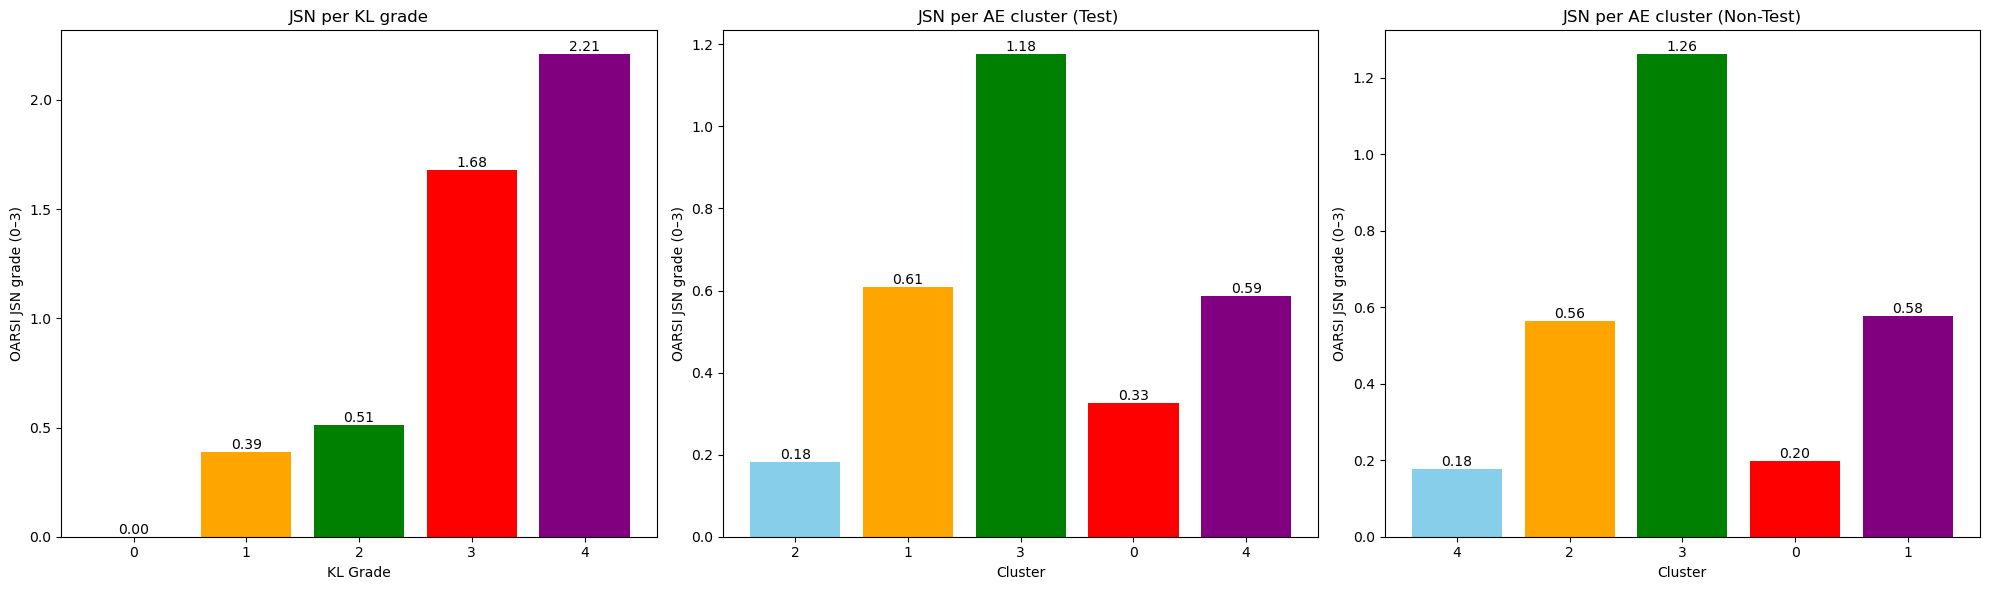

In [3]:
#  FIXED CLUSTER ORDER FOR DISPLAY
# ----------------------------------------------------------
# cluster_order = [4, 1, 2, 0, 3]
cluster_order = [4, 2, 3, 0, 1]
cluster_order_test=[2,1,3,0,4]

colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# ----------------------------------------------------------
#  REORDER AE CLUSTERS (LEFT PLOT)
# ----------------------------------------------------------
tabular_input_data_test = (
    tabular_input_data_test
    .set_index("cluster")
    .loc[cluster_order_test]
    .reset_index()
)
tabular_input_data_non_test = (
    tabular_input_data_non_test
    .set_index("cluster")
    .loc[cluster_order]
    .reset_index()
)

x = np.arange(len(cluster_order))

# # ----------------------------------------------------------
# #  COMPUTE MATCHING BETWEEN AE CLUSTERS AND PAIN CLUSTERS
# #     (based on JSN: V00XRJSM_L_MEAN)
# # ----------------------------------------------------------

# left_jsn  = cluster_data_sorted['V00XRJSM_L_MEAN'].values
# right_jsn = cluster_pain_data.set_index("cluster").loc[cluster_order]['V00XRJSM_L_MEAN'].values

# diff_matrix = np.abs(left_jsn[:, None] - right_jsn[None, :])

# mapping = {}
# remaining_left  = list(range(5))
# remaining_right = list(range(5))

# for _ in range(5):
#     sub = diff_matrix[np.ix_(remaining_left, remaining_right)]
#     i, j = divmod(sub.argmin(), sub.shape[1])

#     left_cluster  = cluster_order[remaining_left[i]]
#     right_cluster = cluster_order[remaining_right[j]]

#     mapping[right_cluster] = left_cluster

#     del remaining_left[i]
#     del remaining_right[j]

# print("\nJSN-based cluster mapping (pain → AE):")
# print(mapping)

# # ----------------------------------------------------------
# #  APPLY MAPPING TO PAIN CLUSTERS
# # ----------------------------------------------------------
# cluster_pain_data['mapped_cluster'] = cluster_pain_data['cluster'].map(mapping)

# cluster_pain_sorted = (
#     cluster_pain_data
#     .set_index("mapped_cluster")
#     .loc[cluster_order]
#     .reset_index()
# )

# ----------------------------------------------------------
#  PLOTTING
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# fig.patch.set_alpha(0)      # transparent figure background


# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['axes.titlecolor'] = 'white'
# --------------------- PANEL 1 ---------------------
bars = axes[0].bar(
    kl_data['KL_GRADE'],
    kl_data['V00XRJSM_L'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha='center', va='bottom')

axes[0].set_title("JSN per KL grade")
axes[0].set_xlabel("KL Grade")
axes[0].set_ylabel("OARSI JSN grade (0–3)")

# --------------------- PANEL 2  --------------------
bars = axes[1].bar(
    x,
    tabular_input_data_test['V00XRJSM_L_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha='center', va='bottom')

axes[1].set_title("JSN per AE cluster (Test) ")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("OARSI JSN grade (0–3)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cluster_order_test)

# --------------------- PANEL 3 ---------------------
bars = axes[2].bar(
    x,
    tabular_input_data_non_test['V00XRJSM_L_MEAN'],
    color=colors
)
for bar in bars:
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h, f"{h:.2f}",
                 ha='center', va='bottom')

axes[2].set_title("JSN per AE cluster (Non-Test)")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("OARSI JSN grade (0–3)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(cluster_order)

plt.tight_layout()
plt.show()


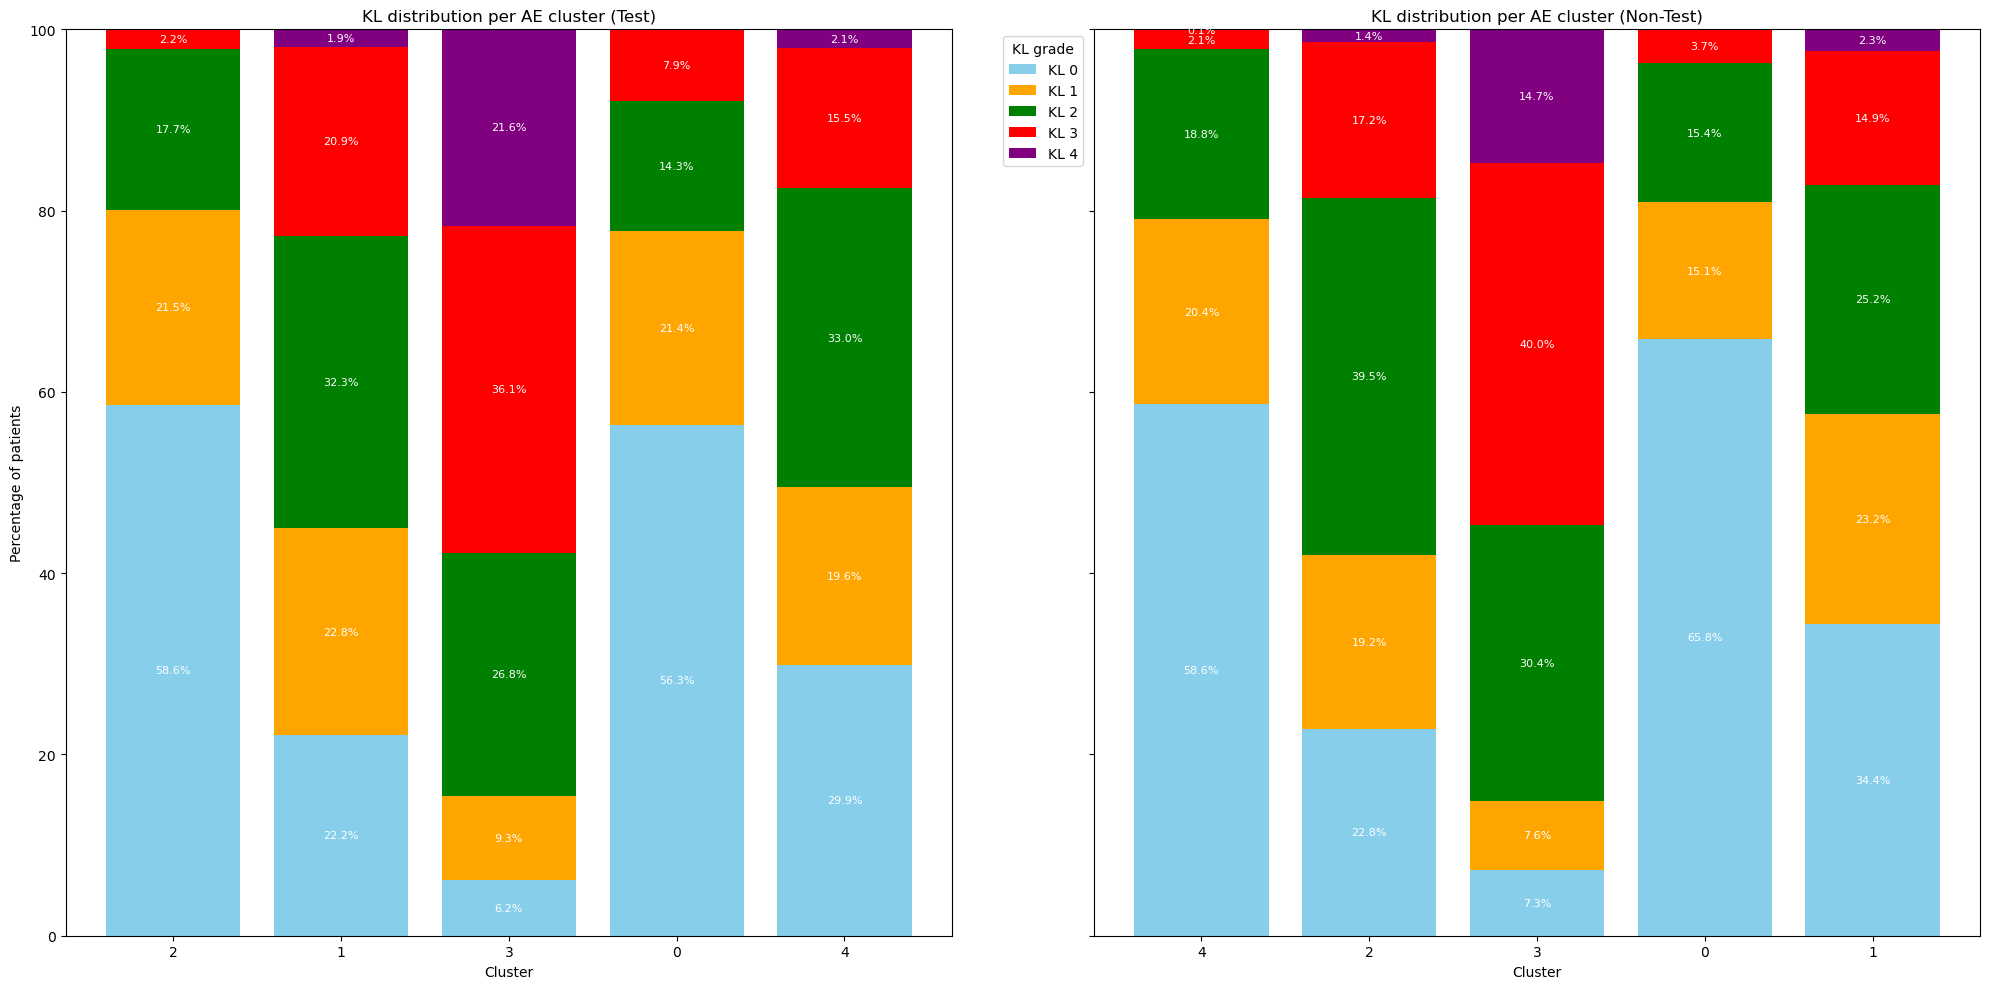

In [4]:
# Stacked bar chart of KL grade distribution per cluster

kl_cols = ["KL_LEFT_0_PCT", "KL_LEFT_1_PCT", "KL_LEFT_2_PCT", "KL_LEFT_3_PCT", "KL_LEFT_4_PCT"]
labels = ["KL 0", "KL 1", "KL 2", "KL 3", "KL 4"]
# cluster_order = [4, 1, 2, 0, 3]  # keep same order as earlier
cluster_order = [4, 2, 3, 0, 1]
cluster_order_test=[2,1,3,0,4]

colors_kl = ['skyblue', 'orange', 'green', 'red', 'purple']


fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharey=True)
# fig.patch.set_alpha(0)      # transparent figure background


# plt.rcParams['axes.labelcolor'] = 'white'
# plt.rcParams['xtick.color'] = 'white'
# plt.rcParams['ytick.color'] = 'white'
# plt.rcParams['axes.titlecolor'] = 'white'

# ---------- first clusters ----------
cd_sorted = tabular_input_data_test.set_index("cluster").loc[cluster_order_test].reset_index()

x = np.arange(len(cluster_order))
bottom = np.zeros(len(cluster_order))

for col, label, c in zip(kl_cols, labels, colors_kl):
    vals = cd_sorted[col].values * 100  # convert to %
    bars = axes[0].bar(x, vals, bottom=bottom, label=label, color=c)
    # add text on each segment
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white"
            )
    bottom += vals

axes[0].set_title("KL distribution per AE cluster (Test)")
axes[0].set_xlabel("Cluster")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cluster_order_test)
axes[0].set_ylabel("Percentage of patients")
axes[0].legend(title="KL grade", bbox_to_anchor=(1.05, 1), loc="upper left")

# ---------- second clusters ----------
cp_sorted = tabular_input_data_non_test.set_index("cluster").loc[cluster_order].reset_index()
x2 = np.arange(len(cluster_order))
bottom = np.zeros(len(cluster_order))

for col, label, c in zip(kl_cols, labels, colors_kl):
    vals = cp_sorted[col].values * 100
    bars = axes[1].bar(x2, vals, bottom=bottom, label=label, color=c)
    for bar, v, b in zip(bars, vals, bottom):
        if v > 0:
            axes[1].text(
                bar.get_x() + bar.get_width() / 2,
                b + v / 2,
                f"{v:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white"
            )
    bottom += vals

axes[1].set_title("KL distribution per AE cluster (Non-Test)")
axes[1].set_xlabel("Cluster")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(cluster_order)

plt.tight_layout()
plt.show()